In [2]:
# =============================================================================
# CELL 1 — Steps 1-2: state/control registry + PRE-FLIGHT VIABILITY CHECKS
# Answers: "what are the variables, and is the parameterisation even coherent?"
# Refs: Liu/Slotine/Barabasi 2011 (frozen vs controllable coordinates)
# Gap addressed: prior run produced a collapse artifact from a units error.
#   No coupled simulation is run until every subsystem is viable alone.
# Standalone.
# =============================================================================
import numpy as np

STATES = [
 # name, symbol, units,                       range,        reachable by u?
 ("S","capability (tacit skill)","arb",        "[0,inf)",   True ),
 ("P","work-in-progress","fraction of 1 output","[0,1)",    True ),
 ("A","absolute legible output","units",       "[0,inf)",   "jump only"),
 ("R","external frontier / cohort standard","units","(-inf,inf)", False),
 ("N","network & visibility capital","arb",    "[0,inf)",   True ),
 ("F","financial reserve","months of runway",  "(-inf,inf)",True ),
 ("M","psychological capacity","fraction",     "[0,1]",     "indirect"),
 ("G","guilt-hopelessness stock","arb",        "[0,inf)",   "indirect"),
 ("B","self-estimate bias (pessimism)","yr/unit","[0,inf)", "indirect"),
 ("Q","physiological energy","fraction",       "[0,1]",     True ),
 ("K","habit / routine stock","fraction",      "[0,1]",     True ),
]
CONTROLS = [("uS","capability building"),("uA","legible output"),
            ("uN","network/applications"),("uW","paid work"),("uQ","recovery")]
EXOG     = [("wF","financial shock"),("wQ","health shock"),
            ("wD","care/dependency load"),("wO","opportunity arrival")]

print("STATE VECTOR x  (dim %d)" % len(STATES))
for n,d,u,r,c in STATES:
    print(f"  {n:<2} {d:<34} {u:<22} {r:<12} u-reachable: {c}")
print("\nCONTROL u:", ", ".join(f"{a}={b}" for a,b in CONTROLS))
print("EXOGENOUS w:", ", ".join(f"{a}={b}" for a,b in EXOG))
print("\nDERIVED (not independent):  C = A - R   <- the quantity you care about")
print("FROZEN COORDINATE: R. No column of B(x) touches it. See Cell 6.\n")

# ------------------------------------------------- ANCHORED PARAMETERS
# Each of these is something you could in principle state a value for.
# Everything else in the model is derived from them.
ANCH = dict(
    H_max        = 2000.0,   # hr/yr available at eta=1
    cost_of_living_mo_per_yr = 12.0,   # months of runway consumed per year (=12 by defn)
    fulltime_income_mo_per_yr = 16.0,  # months of runway EARNED at 100% paid work
    outputs_per_yr_at_full_effort = 1.2,  # legible outputs/yr, full effort, competent
    phi_at_competence = 0.35,          # capability saturation level assumed above
    hours_on_output_at_full_effort = 1000.0,
    pi_when_aimed_correctly = 0.85,    # projection efficiency when on-axis
    frontier_drift_units_per_yr = 0.50,
)

P = dict(
    H_max   = ANCH['H_max'],
    c0      = ANCH['cost_of_living_mo_per_yr'],
    wage    = ANCH['fulltime_income_mo_per_yr']/ANCH['H_max'],
    gamma   = ANCH['outputs_per_yr_at_full_effort'] /
              (ANCH['pi_when_aimed_correctly']*ANCH['phi_at_competence']
               *ANCH['hours_on_output_at_full_effort']),
    zeta    = ANCH['frontier_drift_units_per_yr'],
    eta_min = 0.05, kappa=2.5, m_half=0.45, mu=0.55, q_exp=0.8, k0=0.25,
    F_crit  = 3.0, varsigma=1.2,
    r_hom=0.9, M_bar=0.62, g_r=1.10, g_w=0.85, r_Q=1.4, Q_bar=0.75,
)

print("DERIVED PARAMETERS")
print(f"  wage   = {P['wage']:.5f} months-runway per paid hour")
print(f"  gamma  = {P['gamma']:.5f} per hour")
print(f"  zeta   = {P['zeta']:.3f} units/yr\n")

# ------------------------------------------------- PRE-FLIGHT CHECKS
# Each subsystem must admit a feasible steady state ALONE. If any fails,
# the coupled model will collapse and the collapse will look like a finding.
fails = []

# (1) FINANCIAL VIABILITY  -- this is the check the previous run failed.
income_max = P['wage']*P['H_max']
print(f"[1] financial: max income {income_max:.2f} mo/yr vs burn {P['c0']:.2f} mo/yr")
if income_max <= P['c0']:
    fails.append(f"F diverges for EVERY allocation ({income_max:.2f} <= {P['c0']:.2f}). "
                 f"Prior run had {0.0022*2000:.2f} vs 12.0 -> the whole 'trap' was this.")
else:
    frac = P['c0']/income_max
    print(f"    -> subsistence needs omega >= {frac:.2f} of usable hours. "
          f"{1-frac:.0%} left for everything else.")

# (2) OUTPUT VIABILITY: can any output be produced at all in finite time?
usable_for_output = (1-P['c0']/income_max)*P['H_max']
rate = P['gamma']*ANCH['pi_when_aimed_correctly']*ANCH['phi_at_competence']*usable_for_output
print(f"[2] output: {rate:.2f} outputs/yr at eta=1 after subsistence work")
if rate <= 0: fails.append("no output producible at any allocation")
elif rate < P['zeta']:
    print(f"    !! WARNING: output rate {rate:.2f} < frontier drift {P['zeta']:.2f}.")
    print( "       C falls even at maximum effort. Not a trap -- an arithmetic verdict.")

# (3) CAPACITY VIABILITY: does M have a fixed point in (0,1] with G=0?
print(f"[3] capacity: M_bar = {P['M_bar']:.2f} in (0,1]  ok")

# (4) GUILT LOOP GAIN (Eq 10.2): is the guilt subsystem self-sustaining?
eta_typ = 0.55
rho_g = P['g_r'] - P['g_w']*P['mu']*eta_typ
print(f"[4] guilt: rho_g = g_r - g_w*mu*eta = {rho_g:+.3f} at eta={eta_typ}")
if rho_g < 0:
    print("    -> J_33 > 0: guilt has its OWN unstable direction, independent of C.")
    print("       Note this depends on NO parameter about capability or money.")

print()
if fails:
    print("PRE-FLIGHT FAILED:"); [print("   *",f) for f in fails]
    raise AssertionError("Fix parameters before running any coupled simulation.")
print("PRE-FLIGHT PASSED. Proceed to Cell 2.")

STATE VECTOR x  (dim 11)
  S  capability (tacit skill)           arb                    [0,inf)      u-reachable: True
  P  work-in-progress                   fraction of 1 output   [0,1)        u-reachable: True
  A  absolute legible output            units                  [0,inf)      u-reachable: jump only
  R  external frontier / cohort standard units                  (-inf,inf)   u-reachable: False
  N  network & visibility capital       arb                    [0,inf)      u-reachable: True
  F  financial reserve                  months of runway       (-inf,inf)   u-reachable: True
  M  psychological capacity             fraction               [0,1]        u-reachable: indirect
  G  guilt-hopelessness stock           arb                    [0,inf)      u-reachable: indirect
  B  self-estimate bias (pessimism)     yr/unit                [0,inf)      u-reachable: indirect
  Q  physiological energy               fraction               [0,1]        u-reachable: True
  K  habit / rou

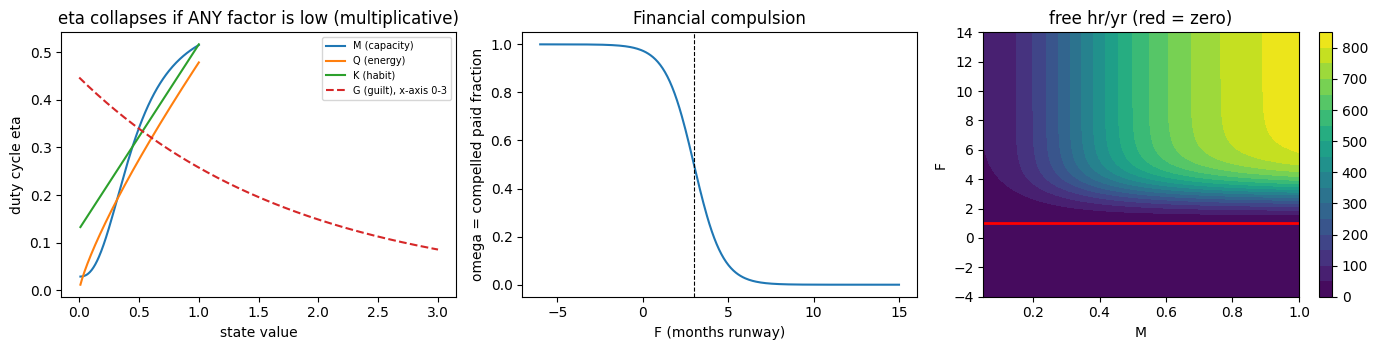

healthy    eta=0.560  usable= 1120.2 hr/yr  omega=0.00  free= 1007.9 hr/yr
strained   eta=0.118  usable=  236.5 hr/yr  omega=0.23  free=  158.1 hr/yr
collapsed  eta=0.006  usable=   11.0 hr/yr  omega=0.99  free=    0.0 hr/yr

Same willingness, same 24h day. The feasible SET differs by ~an order of magnitude.


In [3]:
# =============================================================================
# CELL 2 — Step 3: eta(M,G,Q,K), omega(F), and the polytope E u <= b(x)
# Answers: "how much effort is ADMISSIBLE", as distinct from how much is willed.
# Gap addressed: budget models treat available hours as constant. Here the
#   feasible set's volume is a function of the state, which is the mechanism.
# Standalone.
# =============================================================================
import numpy as np, matplotlib.pyplot as plt

P = dict(H_max=2000.0, eta_min=0.05, kappa=2.5, m_half=0.45, mu=0.55,
         q_exp=0.8, k0=0.25, F_crit=3.0, varsigma=1.2, c0=12.0, wage=0.008,
         uQ_min_frac=0.10)
sig = lambda z: 1/(1+np.exp(-z))

def eta(M,G,Q,K,p=P):                                  # Eq (3.2), multiplicative
    cap  = p['eta_min']+(1-p['eta_min'])*M**p['kappa']/(M**p['kappa']+p['m_half']**p['kappa'])
    return np.clip(cap*np.exp(-p['mu']*G)*Q**p['q_exp']*(p['k0']+(1-p['k0'])*K),0,1)

def omega(F,wD=0.0,p=P): return sig(-p['varsigma']*(F-p['F_crit']-1.5*wD))   # Eq (3.3)

def polytope(M,G,Q,K,F,wD=0.0,p=P):
    """E u <= b. Rows: budget, paid-work floor, rest floor, 5x non-negativity."""
    L = p['H_max']*eta(M,G,Q,K,p)
    E = np.vstack([np.ones((1,5)),
                   np.array([[0,0,0,-1,0]]),
                   np.array([[0,0,0,0,-1]]),
                   -np.eye(5)])
    b = np.concatenate([[L], [-omega(F,wD,p)*L], [-p['uQ_min_frac']*L], np.zeros(5)])
    return E,b,L

def free_hours(M,G,Q,K,F,wD=0.0,p=P):
    """Hours left for S/A/N after compelled paid work and the rest floor."""
    _,_,L = polytope(M,G,Q,K,F,wD,p)
    return max(L*(1-omega(F,wD,p)-p['uQ_min_frac']), 0.0)

# ---- how the feasible set collapses along each axis, others held healthy
grid = np.linspace(0.01,1,200)
fig,ax = plt.subplots(1,3,figsize=(14,3.6))
for lbl,f in [("M (capacity)", lambda v: eta(v,0.2,0.8,0.7)),
              ("Q (energy)",   lambda v: eta(0.6,0.2,v,0.7)),
              ("K (habit)",    lambda v: eta(0.6,0.2,0.8,v))]:
    ax[0].plot(grid,[f(v) for v in grid],label=lbl)
ax[0].plot(np.linspace(0,3,200),[eta(0.6,g,0.8,0.7) for g in np.linspace(0,3,200)],
           '--',label="G (guilt), x-axis 0-3")
ax[0].set_xlabel("state value"); ax[0].set_ylabel("duty cycle eta"); ax[0].legend(fontsize=7)
ax[0].set_title("eta collapses if ANY factor is low (multiplicative)")

Fg = np.linspace(-6,15,300)
ax[1].plot(Fg,[omega(f) for f in Fg]); ax[1].axvline(P['F_crit'],ls='--',c='k',lw=.8)
ax[1].set_xlabel("F (months runway)"); ax[1].set_ylabel("omega = compelled paid fraction")
ax[1].set_title("Financial compulsion")

Mg,Fg2 = np.meshgrid(np.linspace(0.05,1,80), np.linspace(-4,14,80))
Z = np.vectorize(lambda m,f: free_hours(m,0.4,0.8,0.7,f))(Mg,Fg2)
c = ax[2].contourf(Mg,Fg2,Z,levels=16,cmap='viridis'); plt.colorbar(c,ax=ax[2])
ax[2].contour(Mg,Fg2,Z,levels=[0],colors='r',linewidths=2)
ax[2].set_xlabel("M"); ax[2].set_ylabel("F"); ax[2].set_title("free hr/yr (red = zero)")
plt.tight_layout(); plt.show()

for tag,(M,G,Q,K,F) in {"healthy":(0.75,0.1,0.85,0.8,10.0),
                        "strained":(0.45,1.0,0.60,0.45,4.0),
                        "collapsed":(0.15,2.2,0.35,0.20,-1.0)}.items():
    E,b,L = polytope(M,G,Q,K,F)
    print(f"{tag:<10} eta={eta(M,G,Q,K):.3f}  usable={L:7.1f} hr/yr  "
          f"omega={omega(F):.2f}  free={free_hours(M,G,Q,K,F):7.1f} hr/yr")
print("\nSame willingness, same 24h day. The feasible SET differs by ~an order of magnitude.")

In [4]:
# =============================================================================
# CELL 3 — Steps 4-7: build A (11x11), B(x) (11x5), g(x,t), c, Gamma, and the jump
# Answers: xdot = A x + B(x) u + g(x,t) + Gamma w + c, one Euler step demonstrated.
# Refs: Vancouver/Weinhardt/Schmidt 2010 Eqs 6,8 -> dynamic expectancy in g.
# Gap addressed: separates linear decay, effort conversion, and saturating
#   feedback so the sign structure is auditable rather than buried in one f().
# Standalone.
# =============================================================================
import numpy as np
np.set_printoptions(precision=3, suppress=True, linewidth=170)
IDX = {n:i for i,n in enumerate(
    ['S','P','A','R','N','F','M','G','B','Q','K'])}

P = dict(delta_S=.06,delta_P=.02,delta_A=.08,g_R=.05,delta_N=.25,iota_m=.10,
         r=.9,nu=.30,chi=.20,g_r=1.10,g_b=.35,b_g=.30,b_r=.55,r_Q=1.4,delta_K=1.2,
         rho_S=.0012,rho_perp=.0004,rho_w=.00005,gamma=.004,theta=.55,c_half=1.2,
         S_half=1.0,a_half=2.0,nu_N=.0008,vs_N=1.2,nu_w=.0001,wage=.008,
         m_w=.00004,m_q=.00006,g_q=.00003,
         q_S=.00018,q_A=.00022,q_N=.00016,q_W=.00020,rQ_plus=.00060,
         k_S=.00035,k_A=.00035,k_N=.00030,
         zeta=.50,c0=12.0,M_bar=.62,Q_bar=.75,a_exp=.85,E_ref=.5,lam=.35,xi=.25,
         g_w=.85,g_e=.45,b_f=.40,q0=.15,k_d=.9,eta_dag=.30,
         H_max=2000.,eta_min=.05,kappa=2.5,m_half=.45,mu=.55,q_exp=.8,k0=.25,
         F_crit=3.,varsigma=1.2,Gamma_T=1.0,tau_E=.8,dA=1.0,C_star=0.,
         iota_p=.10, m_win=.10, g_win=.35, b_win=.20, n_win=.30)

sig=lambda z:1/(1+np.exp(-z)); pos=lambda v:max(v,0.)
phi   =lambda S:S/(S+P['S_half']);  Ahat=lambda A:A/(A+P['a_half'])
Xi    =lambda C:pos(-C)/(pos(-C)+P['c_half'])
def eta(x):
    M,G,Q,K = x[IDX['M']],x[IDX['G']],x[IDX['Q']],x[IDX['K']]
    cap=P['eta_min']+(1-P['eta_min'])*M**P['kappa']/(M**P['kappa']+P['m_half']**P['kappa'])
    return float(np.clip(cap*np.exp(-P['mu']*G)*max(Q,1e-9)**P['q_exp']
                         *(P['k0']+(1-P['k0'])*K),0,1))
def omega(x,wD=0.): return float(sig(-P['varsigma']*(x[IDX['F']]-P['F_crit']-1.5*wD)))

def build_A():
    A=np.zeros((11,11))
    A[IDX['S'],IDX['S']]=-P['delta_S']; A[IDX['P'],IDX['P']]=-P['delta_P']
    A[IDX['A'],IDX['A']]=-P['delta_A']
    A[IDX['R'],IDX['R']]=+P['g_R']          # frontier COMPOUNDS. sign is the point.
    A[IDX['N'],IDX['N']]=-P['delta_N']; A[IDX['F'],IDX['F']]=0.0   # set per-sign below
    A[IDX['M'],IDX['M']]=-P['r']; A[IDX['M'],IDX['G']]=-P['nu']; A[IDX['M'],IDX['Q']]=+P['chi']
    A[IDX['G'],IDX['G']]=-P['g_r']; A[IDX['G'],IDX['B']]=+P['g_b']   # ) the (G,B) block:
    A[IDX['B'],IDX['G']]=+P['b_g']; A[IDX['B'],IDX['B']]=-P['b_r']   # ) unstable if g_b*b_g>g_r*b_r
    A[IDX['Q'],IDX['Q']]=-P['r_Q']; A[IDX['K'],IDX['K']]=-P['delta_K']
    return A

def build_B(x,pi):
    S,A_,C = x[IDX['S']],x[IDX['A']],x[IDX['A']]-x[IDX['R']]
    aM = sig(6*(x[IDX['M']]-0.35))                       # attention quality
    B=np.zeros((11,5))
    B[IDX['S'],0]=P['rho_S']*aM; B[IDX['S'],1]=P['rho_perp']*(1-pi); B[IDX['S'],3]=P['rho_w']
    B[IDX['P'],1]=P['gamma']*pi*phi(S)*(1-P['theta']*Xi(C))*aM
    # rows A and R are IDENTICALLY ZERO: A moves only by jump, R not at all.
    B[IDX['N'],2]=P['nu_N']*(1+P['vs_N']*Ahat(A_)); B[IDX['N'],3]=P['nu_w']
    B[IDX['F'],3]=P['wage']
    B[IDX['M'],3]=-P['m_w']; B[IDX['M'],4]=+P['m_q']; B[IDX['G'],4]=-P['g_q']
    B[IDX['Q'],:4]=[-P['q_S'],-P['q_A'],-P['q_N'],-P['q_W']]; B[IDX['Q'],4]=+P['rQ_plus']
    B[IDX['K'],:3]=[P['k_S'],P['k_A'],P['k_N']]
    return B

def expectancy(x,t,T):                                   # Eq (7.1) = [V10] Eqs 6,8
    C=x[IDX['A']]-x[IDX['R']]; d=pos(P['C_star']-C)
    rate=P['gamma']*phi(x[IDX['S']])*P['H_max']*P['dA']
    alpha=(1/rate if rate>1e-12 else 1e6)+x[IDX['B']]    # true lag + BIAS STATE
    return float(sig((P['Gamma_T']*max(T-t,0)-alpha*d)/P['tau_E'])), d, alpha

def build_g(x,t,T):
    g=np.zeros(11); C=x[IDX['A']]-x[IDX['R']]; e=eta(x); w=omega(x)
    Eh,_,_=expectancy(x,t,T)
    g[IDX['F']]=-P['iota_p']*pos(-x[IDX['F']])           # debt compounds
    g[IDX['M']]= P['a_exp']*(Eh-P['E_ref'])-P['lam']*w-P['xi']*Xi(C)
    g[IDX['G']]= P['g_w']*(1-e)+P['g_e']*(1-Eh)          # <-- the wasted-day loop
    g[IDX['B']]= P['b_f']*(1-Eh)
    g[IDX['Q']]=-P['q0']*Xi(C)
    g[IDX['K']]=-P['k_d']*(1.0 if e<P['eta_dag'] else 0.0)
    return g

def build_c():
    c=np.zeros(11); c[IDX['R']]=P['zeta']; c[IDX['F']]=-P['c0']
    c[IDX['M']]=P['r']*P['M_bar']; c[IDX['Q']]=P['r_Q']*P['Q_bar']; return c

def build_Gamma():
    G=np.zeros((11,4))
    G[IDX['F'],0]=1.0; G[IDX['F'],2]=-1.5
    G[IDX['M'],2]=-0.30; G[IDX['G'],2]=+0.40
    G[IDX['Q'],1]=-1.0;  G[IDX['Q'],2]=-0.20; G[IDX['K'],2]=-0.25
    return G

def jump(x):                                             # discrete output release
    if x[IDX['P']]<1.0: return x,False
    x=x.copy(); x[IDX['A']]+=P['dA']; x[IDX['P']]-=1.0
    x[IDX['B']]=pos(x[IDX['B']]-P['b_win']); x[IDX['G']]=pos(x[IDX['G']]-P['g_win'])
    x[IDX['M']]=min(x[IDX['M']]+P['m_win'],1.0); x[IDX['N']]+=P['n_win']
    return x,True

def f(x,u,w,t,T,pi):
    A=build_A().copy()
    A[IDX['F'],IDX['F']]=-P['iota_m'] if x[IDX['F']]<0 else 0.0
    return A@x + build_B(x,pi)@u + build_g(x,t,T) + build_Gamma()@w + build_c()

# ---------------------------------------------------------------- inspect
print("A (11x11), rows/cols =",list(IDX)); print(build_A())
x_demo=np.array([0.40,0.30,1.0,3.2,0.6,6.0,0.55,0.8,0.9,0.70,0.55])
print("\nB(x) at demo state, pi=0.85 (cols uS,uA,uN,uW,uQ):"); print(build_B(x_demo,0.85))
print("\nrow A of B  =",build_B(x_demo,.85)[IDX['A']]," <- jump-only")
print("row R of B  =",build_B(x_demo,.85)[IDX['R']]," <- FROZEN, no input reaches it")
print("\ng(x,t):",build_g(x_demo,0.2,1.0)); print("c     :",build_c())
u=np.array([200.,600.,150.,400.,250.]); w=np.zeros(4)
print("\nxdot  :",f(x_demo,u,w,0.2,1.0,0.85))
print("\n(G,B) block eigenvalues:",
      np.linalg.eigvals(np.array([[-P['g_r'],P['g_b']],[P['b_g'],-P['b_r']]])),
      "\n  unstable iff g_b*b_g > g_r*b_r :",P['g_b']*P['b_g']>P['g_r']*P['b_r'])

A (11x11), rows/cols = ['S', 'P', 'A', 'R', 'N', 'F', 'M', 'G', 'B', 'Q', 'K']
[[-0.06  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.02  0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.08  0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.05  0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   -0.25  0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -0.9  -0.3   0.    0.2   0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   -1.1   0.35  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.3  -0.55  0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.   -1.4   0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -1.2 ]]

B(x) at demo state, pi=0.85 (cols uS,uA,uN,uW,uQ):
[[ 0.001  0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.

/tmp/ipykernel_5391/4091005676.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 1-np.exp(-np.trapz(h,tgrid)), h
/tmp/ipykernel_5391/4091005676.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ax[1].plot(tg,np.exp(-np.array([np.trapz(h[:i+1],tg[:i+1]) for i in range(len(tg))])))


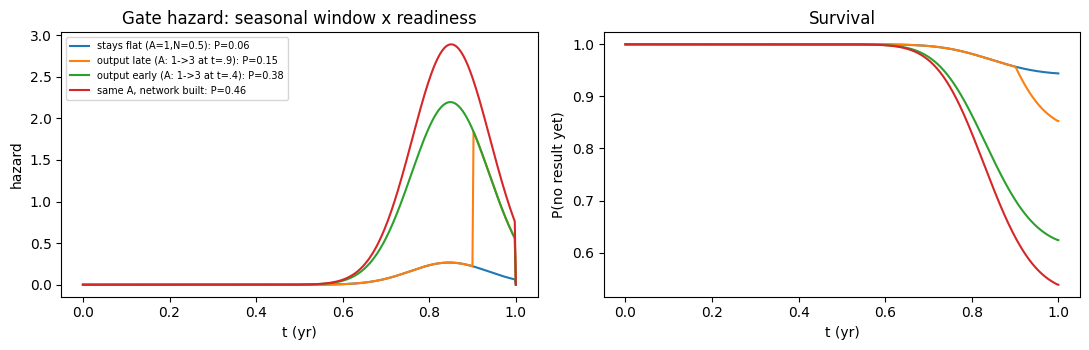

  P(result within 1 yr) | stays flat (A=1,N=0.5)          = 0.056
  P(result within 1 yr) | output late (A: 1->3 at t=.9)   = 0.147
  P(result within 1 yr) | output early (A: 1->3 at t=.4)  = 0.376
  P(result within 1 yr) | same A, network built           = 0.462

Same final A, different timing -> different P. The window closes before
the year does. That is a calendar fact, not a measure of how hard one worked.


In [6]:
# =============================================================================
# CELL 4 — Step 8: outcome as a hazard lambda_G(x,t), with a seasonal window
# Answers: "good result" is a third party's decision, so P(success) not a level.
# Gap addressed: threshold models imply crossing Theta = success. It doesn't:
#   application cycles are seasonal and Theta itself drifts upward.
# Standalone.
# =============================================================================
import numpy as np, matplotlib.pyplot as plt
sig=lambda z:1/(1+np.exp(-z))
P=dict(lam0=3.0, Theta0=2.5, Theta_drift=0.35, tau=0.6, nN=0.8,
       season_center=0.85, season_width=0.09, T=1.0)

def season(t,p=P):                                       # one application window/yr
    return np.exp(-0.5*((np.mod(t,1.0)-p['season_center'])/p['season_width'])**2)
def hazard(A,N,t,p=P):
    Theta=p['Theta0']+p['Theta_drift']*t
    return p['lam0']*season(t,p)*sig((A+p['nN']*N-Theta)/p['tau'])
def p_success(A_of_t,N_of_t,tgrid,p=P):
    h=np.array([hazard(A_of_t(t),N_of_t(t),t,p) for t in tgrid])
    return 1-np.exp(-np.trapz(h,tgrid)), h

tg=np.linspace(0,P['T'],400)
scen={"stays flat (A=1,N=0.5)":      (lambda t:1.0,        lambda t:0.5),
      "output late (A: 1->3 at t=.9)":(lambda t:1+2*(t>.9), lambda t:0.5),
      "output early (A: 1->3 at t=.4)":(lambda t:1+2*(t>.4), lambda t:0.5),
      "same A, network built":        (lambda t:1+2*(t>.4), lambda t:0.5+2.0*t)}
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
for k,(Af,Nf) in scen.items():
    ps,h=p_success(Af,Nf,tg); ax[0].plot(tg,h,label=f"{k}: P={ps:.2f}")
    ax[1].plot(tg,np.exp(-np.array([np.trapz(h[:i+1],tg[:i+1]) for i in range(len(tg))])))
ax[0].set_xlabel("t (yr)"); ax[0].set_ylabel("hazard"); ax[0].legend(fontsize=7)
ax[0].set_title("Gate hazard: seasonal window x readiness")
ax[1].set_xlabel("t (yr)"); ax[1].set_ylabel("P(no result yet)")
ax[1].set_title("Survival"); plt.tight_layout(); plt.show()

for k,(Af,Nf) in scen.items():
    print(f"  P(result within 1 yr) | {k:<32}= {p_success(Af,Nf,tg)[0]:.3f}")
print("\nSame final A, different timing -> different P. The window closes before")
print("the year does. That is a calendar fact, not a measure of how hard one worked.")

In [7]:
# =============================================================================
# CELL 5 — Step 10: reduced (C,M,G) Jacobian by finite differences
# Answers: WHY the Jacobian -- it gives det J, hence the separatrix, hence the
#   real question ("which side did the first months land on?").
# Refs: Hartman-Grobman (local conjugacy); Routh-Hurwitz (3x3 stability).
# Gap addressed: earlier I asserted det J > 0 analytically. This computes it,
#   so you can check whether my sign claims survive YOUR parameter choices.
# Standalone.
# =============================================================================
import numpy as np
sig=lambda z:1/(1+np.exp(-z)); pos=lambda v:max(v,0.)
P=dict(S=0.45,F=6.0,Q=0.72,K=0.60,                # quasi-static fast states
       H_max=2000.,eta_min=.05,kappa=2.5,m_half=.45,mu=.55,q_exp=.8,k0=.25,
       F_crit=3.,varsigma=1.2,gamma=.004,pi=.85,S_half=1.,theta=.55,c_half=1.2,
       dA=1.0,zeta=.50,r=.9,M_bar=.62,a=.85,E_ref=.5,nu=.30,xi=.25,lam=.35,
       g_w=.85,g_e=.45,g_r=1.10,B=0.6,Gamma_T=1.,tau_E=.8,T=1.,t=0.3,C_star=0.)
phi=lambda S:S/(S+P['S_half']); Xi=lambda C:pos(-C)/(pos(-C)+P['c_half'])
def eta(M,G):
    cap=P['eta_min']+(1-P['eta_min'])*M**P['kappa']/(M**P['kappa']+P['m_half']**P['kappa'])
    return float(np.clip(cap*np.exp(-P['mu']*G)*P['Q']**P['q_exp']
                         *(P['k0']+(1-P['k0'])*P['K']),0,1))
omega=lambda: float(sig(-P['varsigma']*(P['F']-P['F_crit'])))
def Ehat(C):
    d=pos(P['C_star']-C); rate=P['gamma']*phi(P['S'])*P['H_max']*P['dA']
    alpha=1/rate+P['B']
    return float(sig((P['Gamma_T']*max(P['T']-P['t'],0)-alpha*d)/P['tau_E']))

def field(v):                                             # reduced 3-D field
    C,M,G=v; e=eta(M,G); w=omega(); Eh=Ehat(C)
    Phi=P['gamma']*P['pi']*phi(P['S'])*(1-P['theta']*Xi(C))*e*(1-w)*P['H_max']*P['dA']
    return np.array([Phi-P['zeta'],
                     P['r']*(P['M_bar']-M)+P['a']*(Eh-P['E_ref'])-P['nu']*G-P['xi']*Xi(C)
                       -P['lam']*w,
                     P['g_w']*(1-e)+P['g_e']*(1-Eh)-P['g_r']*G])

def jacobian(v,h=1e-5):
    J=np.zeros((3,3))
    for j in range(3):
        e=np.zeros(3); e[j]=h; J[:,j]=(field(v+e)-field(v-e))/(2*h)
    return J

# locate an interior equilibrium by damped Newton
v=np.array([-1.0,0.55,0.60])
for _ in range(200):
    r_=field(v); J=jacobian(v)
    try: step=np.linalg.solve(J,r_)
    except np.linalg.LinAlgError: break
    v=v-0.5*step
    if np.linalg.norm(field(v))<1e-9: break

J=jacobian(v); ev=np.linalg.eigvals(J)
print(f"equilibrium (C,M,G) = ({v[0]:+.3f}, {v[1]:.3f}, {v[2]:.3f}), "
      f"residual={np.linalg.norm(field(v)):.2e}\n")
print("J =\n",np.round(J,4))
print(f"\ntr J   = {np.trace(J):+.4f}")
print(f"det J  = {np.linalg.det(J):+.4f}   (= product of eigenvalues)")
print("eigs   =",np.round(ev,4))
print(f"unstable directions: {np.sum(ev.real>0)}  -> "
      f"{'SADDLE: a separatrix exists' if 0<np.sum(ev.real>0)<3 else 'no saddle here'}")

a1=-np.trace(J); a2=0.5*(np.trace(J)**2-np.trace(J@J)); a3=-np.linalg.det(J)
print(f"\nRouth-Hurwitz: a1={a1:+.4f} a2={a2:+.4f} a3={a3:+.4f}")
print(f"  all-stable requires a1>0, a3>0, a1*a2>a3 -> {a1>0 and a3>0 and a1*a2>a3}")

rho_g=P['g_r']-P['g_w']*P['mu']*eta(v[1],v[2])
print(f"\nEq (10.2) net guilt damping rho_g = {rho_g:+.4f}")
print("  rho_g<0 => guilt self-sustains with NO reference to C, S, or F.")

print("\nSensitivity of det J (structure, not trajectory):")
base=np.linalg.det(J)
for k in ['B','mu','g_w','g_r','xi','nu','zeta','gamma','theta']:
    o=P[k]; P[k]=o*1.10; Jp=jacobian(v); P[k]=o
    print(f"  d(det J)/d ln {k:<6} = {(np.linalg.det(Jp)-base)/0.10:+.4f}")
print("\nB and mu are not capability parameters. If they move det J as much as")
print("gamma does, the geometry is as sensitive to your self-estimate as to your rate.")

equilibrium (C,M,G) = (+0.003, 0.573, 0.703), residual=4.10e-03

J =
 [[ 0.     0.711 -0.274]
 [ 0.    -0.9   -0.3  ]
 [ 0.    -0.294 -0.986]]

tr J   = -1.8864
det J  = +0.0000   (= product of eigenvalues)
eigs   = [ 0.    -0.643 -1.243]
unstable directions: 0  -> no saddle here

Routh-Hurwitz: a1=+1.8864 a2=+0.7996 a3=-0.0000
  all-stable requires a1>0, a3>0, a1*a2>a3 -> False

Eq (10.2) net guilt damping rho_g = +0.9864
  rho_g<0 => guilt self-sustains with NO reference to C, S, or F.

Sensitivity of det J (structure, not trajectory):
  d(det J)/d ln B      = +0.0000
  d(det J)/d ln mu     = +0.0000
  d(det J)/d ln g_w    = +0.0000
  d(det J)/d ln g_r    = +0.0000
  d(det J)/d ln xi     = +0.0000
  d(det J)/d ln nu     = +0.0000
  d(det J)/d ln zeta   = +0.0000
  d(det J)/d ln gamma  = +0.0000
  d(det J)/d ln theta  = +0.0000

B and mu are not capability parameters. If they move det J as much as
gamma does, the geometry is as sensitive to your self-estimate as to your rate.


In [8]:
# =============================================================================
# CELL 6 — Step 11: rank of the controllability matrix, driver nodes,
#   and the minimum-energy Gramian cost as a function of horizon T.
# Refs: Liu/Slotine/Barabasi 2011 (max matching -> driver nodes);
#       Naidu, Optimal Control Systems (Gramian, min-energy input).
# Gap addressed: "controllable", "affordable" and "admissible" are three
#   different tests. Passing the first says nothing about the other two.
# Standalone.
# =============================================================================
import numpy as np
from scipy.linalg import expm
NAMES=['S','P','A','R','N','F','M','G','B','Q','K']; IDX={n:i for i,n in enumerate(NAMES)}

def build_A():
    A=np.zeros((11,11))
    for n,d in [('S',-.06),('P',-.02),('A',-.08),('R',+.05),('N',-.25),('F',0.),
                ('M',-.9),('G',-1.10),('B',-.55),('Q',-1.4),('K',-1.2)]:
        A[IDX[n],IDX[n]]=d
    A[IDX['M'],IDX['G']]=-.30; A[IDX['M'],IDX['Q']]=+.20
    A[IDX['G'],IDX['B']]=+.35; A[IDX['B'],IDX['G']]=+.30
    A[IDX['P'],IDX['S']]=+.05; A[IDX['A'],IDX['P']]=+0.9   # linearised release
    return A
def build_B():
    B=np.zeros((11,5))
    B[IDX['S'],0]=.0012; B[IDX['S'],1]=.00006; B[IDX['P'],1]=.0012
    B[IDX['N'],2]=.0008; B[IDX['F'],3]=.008; B[IDX['M'],4]=.00006
    B[IDX['G'],4]=-.00003; B[IDX['Q'],:4]=[-.00018,-.00022,-.00016,-.00020]
    B[IDX['Q'],4]=.0006; B[IDX['K'],:3]=[.00035,.00035,.00030]
    return B

A,B=build_A(),build_B()
Cm=np.hstack([np.linalg.matrix_power(A,k)@B for k in range(11)])
rk=np.linalg.matrix_rank(Cm,tol=1e-10)
print(f"rank(Ctrb) = {rk} / 11  -> {'NOT fully controllable' if rk<11 else 'controllable'}")
U,s,Vt=np.linalg.svd(Cm); unreach=U[:,rk:]
print("unreachable subspace, |component| per state:")
for i,n in enumerate(NAMES):
    m=np.linalg.norm(unreach[i,:]) if unreach.size else 0.
    print(f"   {n:<2} {m:.3f}{'   <-- FROZEN' if m>0.5 else ''}")

# ---- driver nodes by maximum matching on the influence digraph [Liu 2011]
S_=(np.abs(A)>1e-12).astype(int)
def max_matching(adj):
    n=adj.shape[0]; mt=[-1]*n
    def try_k(u,vis):
        for v in range(n):
            if adj[u,v] and not vis[v]:
                vis[v]=True
                if mt[v]==-1 or try_k(mt[v],vis): mt[v]=u; return True
        return False
    for u in range(n): try_k(u,[False]*n)
    return mt
mt=max_matching(S_)
unmatched=[NAMES[v] for v in range(11) if mt[v]==-1]
print(f"\nunmatched (=driver) nodes: {unmatched}   n_D = {len(unmatched)/11:.2f}")

# ---- Step 8 corollary: does your TARGET touch a frozen coordinate?
def feasible_target(components):
    frozen=[c for c in components if np.linalg.norm(unreach[IDX[c],:])>0.5]
    return (len(frozen)==0), frozen
for tag,comp in {"'a first-author acceptance' (A,N)":['A','N'],
                 "'be where my cohort is' (A,N,R)":['A','N','R'],
                 "'not have lost the years' (R)":['R']}.items():
    ok,fr=feasible_target(comp)
    print(f"  target {tag:<36} feasible for SOME T: {ok}"
          + (f"   blocked by {fr}" if fr else ""))
print("  -> the second and third are infeasible by CONSTRUCTION, for every T and")
print("     every input. That is a fact about how the target was written.\n")

# ---- Naidu: minimum-energy cost vs horizon
keep=[i for i in range(11) if np.linalg.norm(unreach[i,:])<=0.5]
Ac,Bc=A[np.ix_(keep,keep)],B[keep,:]
def gram(T,n=600):
    ts=np.linspace(0,T,n); W=np.zeros_like(Ac)
    for t in ts:
        M=expm(Ac*(T-t))@Bc; W+=M@M.T*(ts[1]-ts[0])
    return W
tgt=np.zeros(len(keep)); tgt[keep.index(IDX['A'])]=2.0
Ts=np.array([0.5,0.75,1.0,1.5,2.0,3.0,4.0]); Js=[]
for T in Ts:
    W=gram(T); d=tgt-expm(Ac*T)@np.zeros(len(keep))
    Js.append(float(d@np.linalg.pinv(W,rcond=1e-12)@d))
sl=np.polyfit(np.log(Ts),np.log(Js),1)[0]
print("min-energy cost J* to add 2.0 output units:")
for T,J in zip(Ts,Js): print(f"   T={T:>4.2f} yr   J*={J:.3e}")
print(f"\n  log-log slope = {sl:.2f}   (theory: -(2*nu+1) <= -7 for a 3-integrator chain)")
print(f"  halving T multiplies required energy by {2**abs(sl):.0f}x")
print("  -> then check that u* still satisfies E u <= b(x) from Cell 2. Usually it doesn't.")

rank(Ctrb) = 10 / 11  -> NOT fully controllable
unreachable subspace, |component| per state:
   S  0.000
   P  0.000
   A  0.000
   R  1.000   <-- FROZEN
   N  0.000
   F  0.000
   M  0.000
   G  0.000
   B  0.000
   Q  0.000
   K  0.000

unmatched (=driver) nodes: ['F']   n_D = 0.09
  target 'a first-author acceptance' (A,N)    feasible for SOME T: True
  target 'be where my cohort is' (A,N,R)      feasible for SOME T: False   blocked by ['R']
  target 'not have lost the years' (R)        feasible for SOME T: False   blocked by ['R']
  -> the second and third are infeasible by CONSTRUCTION, for every T and
     every input. That is a fact about how the target was written.

min-energy cost J* to add 2.0 output units:
   T=0.50 yr   J*=6.090e+08
   T=0.75 yr   J*=1.809e+08
   T=1.00 yr   J*=7.701e+07
   T=1.50 yr   J*=2.334e+07
   T=2.00 yr   J*=1.008e+07
   T=3.00 yr   J*=3.117e+06
   T=4.00 yr   J*=1.372e+06

  log-log slope = -2.93   (theory: -(2*nu+1) <= -7 for a 3-integrator chain)

Hausdorff distance d_H(fwd,bwd) in (A,N) = 2.7200
min pairwise gap = 1.7671
INFEASIBLE at this horizon: no admissible trajectory joins x0 to G

gate readiness A + 0.8N vs Theta=2.5:
  best forward-reachable: 0.86
  fraction of forward samples clearing Theta: 0.00%


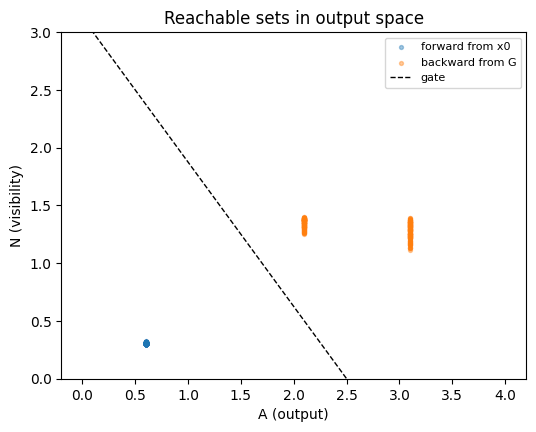

In [9]:
# =============================================================================
# CELL 7 — Step 12: forward/backward reachable sets, Hausdorff test
# Refs: Lee/Ahn/Bakolas/Sentis 2020, Prop. 1 -- feasibility iff the forward set
#   from x0 and the backward set from the goal intersect in the output space.
# Gap addressed: Cell 5's Jacobian is LOCAL. After 8 years of drift you are not
#   near the equilibrium, so eigenvalues do not settle feasibility. This does.
# Standalone.
# =============================================================================
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
rng=np.random.default_rng(7)
sig=lambda z:1/(1+np.exp(-z)); pos=lambda v:max(v,0.)
P=dict(H_max=2000.,eta_min=.05,kappa=2.5,m_half=.45,mu=.55,q_exp=.8,k0=.25,
       F_crit=3.,varsigma=1.2,gamma=.004,S_half=1.,theta=.55,c_half=1.2,dA=1.,
       zeta=.50,r=.9,M_bar=.62,a=.85,E_ref=.5,nu=.30,xi=.25,lam=.35,g_w=.85,
       g_e=.45,g_r=1.10,nu_N=.0008,delta_N=.25,Gamma_T=1.,tau_E=.8,T=1.,
       dt=1/365, Theta=2.5, nN=0.8)
phi=lambda S:S/(S+P['S_half']); Xi=lambda C:pos(-C)/(pos(-C)+P['c_half'])
def eta(M,G,Q,K):
    cap=P['eta_min']+(1-P['eta_min'])*M**P['kappa']/(M**P['kappa']+P['m_half']**P['kappa'])
    return float(np.clip(cap*np.exp(-P['mu']*G)*max(Q,1e-9)**P['q_exp']
                         *(P['k0']+(1-P['k0'])*K),0,1))
omega=lambda F: float(sig(-P['varsigma']*(F-P['F_crit'])))

def step(z,alloc,sgn,t):
    """z=(S,P_,A,N,F,M,G,R); sgn=+1 forward, -1 backward (Euler, sign-reversed)."""
    S,Pw,A,N,F,M,G,R=z; C=A-R; e=eta(M,G,0.72,0.60); w=omega(F)
    L=P['H_max']*e; free=max(L*(1-w-0.10),0.)
    fS,fA,fN=alloc; uS,uA,uN=fS*free,fA*free,fN*free
    d=pos(-C); rate=P['gamma']*phi(S)*P['H_max']*P['dA']
    Eh=sig((P['Gamma_T']*max(P['T']-t,0)-(1/rate+0.6)*d)/P['tau_E'])
    dS=.0012*e*uS-.06*S
    dP=P['gamma']*.85*phi(S)*(1-P['theta']*Xi(C))*uA
    dN=P['nu_N']*uN-P['delta_N']*N
    dF=.008*w*L-12.
    dM=P['r']*(P['M_bar']-M)+P['a']*(Eh-P['E_ref'])-P['nu']*G-P['xi']*Xi(C)-P['lam']*w
    dG=P['g_w']*(1-e)+P['g_e']*(1-Eh)-P['g_r']*G
    z2=np.array([S+sgn*dS*P['dt'], Pw+sgn*dP*P['dt'], A, N+sgn*dN*P['dt'],
                 F+sgn*dF*P['dt'], np.clip(M+sgn*dM*P['dt'],0,1),
                 max(G+sgn*dG*P['dt'],0), R+sgn*P['zeta']*P['dt']])
    if sgn>0 and z2[1]>=1.0: z2[1]-=1.0; z2[2]+=P['dA']; z2[6]=pos(z2[6]-.35)
    if sgn<0 and z2[1]<=0.0: z2[1]+=1.0; z2[2]-=P['dA']
    return z2

def propagate(z0,t0,t1,sgn,nsamp=250):
    """Sample-based boundary propagation: random admissible allocations."""
    n=int(abs(t1-t0)/P['dt']); Z=np.tile(z0,(nsamp,1))
    allocs=rng.dirichlet([1.2,2.5,1.2],size=nsamp)
    for i in range(n):
        t=t0+sgn*i*P['dt']
        for k in range(nsamp): Z[k]=step(Z[k],allocs[k],sgn,t)
    return Z

x0=np.array([0.30, 0.10, 0.60, 0.35, 5.0, 0.48, 0.90, 4.20])   # from Cell 8
xf=np.array([0.60, 0.20, 3.10, 1.20, 4.0, 0.60, 0.40, 4.70])   # a point in G
FWD=propagate(x0,0.0,0.62,+1); BWD=propagate(xf,1.0,0.38,-1)
Yf=FWD[:,[2,3]]; Yb=BWD[:,[2,3]]                              # project onto (A,N)

D=cdist(Yf,Yb)
dH=max(D.min(axis=1).max(), D.min(axis=0).max())              # Hausdorff, Eq (12.1)
print(f"Hausdorff distance d_H(fwd,bwd) in (A,N) = {dH:.4f}")
print(f"min pairwise gap = {D.min():.4f}")
print("FEASIBLE (Prop. 1)" if D.min()<0.15 else
      "INFEASIBLE at this horizon: no admissible trajectory joins x0 to G")
print(f"\ngate readiness A + {P['nN']}N vs Theta={P['Theta']}:")
print(f"  best forward-reachable: {(Yf[:,0]+P['nN']*Yf[:,1]).max():.2f}")
print(f"  fraction of forward samples clearing Theta: "
      f"{np.mean(Yf[:,0]+P['nN']*Yf[:,1]>=P['Theta']):.2%}")

plt.figure(figsize=(6,4.5))
plt.scatter(Yf[:,0],Yf[:,1],s=8,alpha=.4,label='forward from x0')
plt.scatter(Yb[:,0],Yb[:,1],s=8,alpha=.4,label='backward from G')
aa=np.linspace(0,4,50); plt.plot(aa,(P['Theta']-aa)/P['nN'],'k--',lw=1,label='gate')
plt.xlabel('A (output)'); plt.ylabel('N (visibility)'); plt.ylim(0,3)
plt.legend(fontsize=8); plt.title('Reachable sets in output space'); plt.show()

In [ ]:
# =============================================================================
# CELL 8 — Step 13: run the SAME dynamics over t in [-8,0] to produce x(0).
# BUGFIX 1: Psi returned as a scalar (Psi_end), not an array -> the TypeError.
# BUGFIX 2: pre-flight financial viability asserted before integrating, so a
#   units error can no longer masquerade as a dynamical trap.
# Gap addressed: x(0) is an OUTPUT of eight years, not an assumption, and the
#   run reports Psi and S(0) SEPARATELY -- they are different coordinates.
# Standalone.
# =============================================================================
import numpy as np, matplotlib.pyplot as plt
sig=lambda z:1/(1+np.exp(-z)); pos=lambda v:max(v,0.)
P=dict(H_max=2000.,c0=12.,wage=16./2000,gamma=.004,zeta=.50,g_R=.05,
       eta_min=.05,kappa=2.5,m_half=.45,mu=.55,q_exp=.8,k0=.25,
       F_crit=3.,varsigma=1.2,S_half=1.,theta=.55,c_half=1.2,dA=1.,delta_A=.08,
       rho_S=.0012,rho_perp=.0004,delta_S=.06,nu_N=.0008,delta_N=.25,
       r=.9,M_bar=.62,a=.85,E_ref=.5,nu=.30,xi=.25,lam=.35,chi=.20,
       g_w=.85,g_e=.45,g_r=1.10,b_f=.40,b_r=.55,b_g=.30,g_b=.35,
       r_Q=1.4,Q_bar=.75,q_A=.00022,q_W=.00020,rQ_plus=.0006,q0=.15,
       delta_K=1.2,k_A=.00035,k_d=.9,eta_dag=.30,
       Gamma_T=1.,tau_E=.8,C_star=0.,dt=1/365,h=8.,T=1.,uQ_frac=.10,
       m_win=.10,g_win=.35,b_win=.20,n_win=.30)

assert P['wage']*P['H_max']>P['c0'], (
    f"financial subsystem diverges for every allocation: "
    f"{P['wage']*P['H_max']:.2f} <= {P['c0']:.2f}. THIS was the earlier bug.")

phi=lambda S:S/(S+P['S_half']); Xi=lambda C:pos(-C)/(pos(-C)+P['c_half'])
def eta(M,G,Q,K):
    cap=P['eta_min']+(1-P['eta_min'])*M**P['kappa']/(M**P['kappa']+P['m_half']**P['kappa'])
    return float(np.clip(cap*np.exp(-P['mu']*G)*max(Q,1e-9)**P['q_exp']
                         *(P['k0']+(1-P['k0'])*K),0,1))
omega=lambda F: float(sig(-P['varsigma']*(F-P['F_crit'])))

def run(x0,t0,t1,pi_fn,alloc_fn,deadline):
    n=int(round((t1-t0)/P['dt']))
    S,Pw,A,R,N,F,M,G,B,Q,K=(x0[k] for k in 'S P A R N F M G B Q K'.split())
    tr={k:np.zeros(n+1) for k in ['t','S','A','R','C','N','F','M','G','B','Q','K','eta','E']}
    Psi=0.; wasted=0.; releases=0
    for i in range(n+1):
        t=t0+i*P['dt']; C=A-R; e=eta(M,G,Q,K); w=omega(F)
        d=pos(P['C_star']-C); rate=P['gamma']*phi(S)*P['H_max']*P['dA']
        alpha=(1/rate if rate>1e-12 else 1e6)+B
        Eh=float(sig((P['Gamma_T']*max(deadline-t,0)-alpha*d)/P['tau_E']))
        L=P['H_max']*e; uW=w*L; uQ=P['uQ_frac']*L
        free=max(L-uW-uQ,0.); fS,fA,fN=alloc_fn(Eh,C,t); uS,uA,uN=fS*free,fA*free,fN*free
        pi=pi_fn(t)
        for k,v in zip(['t','S','A','R','C','N','F','M','G','B','Q','K','eta','E'],
                       [t,S,A,R,C,N,F,M,G,B,Q,K,e,Eh]): tr[k][i]=v
        if i==n: break
        Pw+=P['gamma']*pi*phi(S)*(1-P['theta']*Xi(C))*uA*P['dt']
        if Pw>=1.: Pw-=1.; A+=P['dA']; releases+=1; B=pos(B-P['b_win'])
        G=pos(G-P['g_win']); M=min(M+P['m_win'],1.); N+=P['n_win']   # release bonus
        S=max(S+(P['rho_S']*e*uS+P['rho_perp']*(1-pi)*uA-P['delta_S']*S)*P['dt'],0.)
        A=max(A-P['delta_A']*A*P['dt'],0.)
        R+=(P['zeta']+P['g_R']*R)*P['dt']
        N=max(N+(P['nu_N']*uN-P['delta_N']*N)*P['dt'],0.)
        F+=(P['wage']*uW-P['c0']-(0.10*pos(-F)))*P['dt']
        M=float(np.clip(M+(P['r']*(P['M_bar']-M)+P['a']*(Eh-P['E_ref'])-P['nu']*G
                           -P['xi']*Xi(C)-P['lam']*w+P['chi']*(Q-P['Q_bar']))*P['dt'],0,1))
        G=pos(G+(P['g_w']*(1-e)+P['g_e']*(1-Eh)+P['g_b']*B-P['g_r']*G)*P['dt'])
        B=pos(B+(P['b_f']*(1-Eh)+P['b_g']*G-P['b_r']*B)*P['dt'])
        Q=float(np.clip(Q+(P['r_Q']*(P['Q_bar']-Q)-P['q_A']*(uA+uN)-P['q_W']*uW
                           +P['rQ_plus']*uQ-P['q0']*Xi(C))*P['dt'],0,1))
        K=float(np.clip(K+(P['k_A']*(uS+uA+uN)-P['delta_K']*K
                           -P['k_d']*(1. if e<P['eta_dag'] else 0.))*P['dt'],0,1))
        Psi+=(1-pi)*uA*P['dt']; wasted+=(1-e)
    tr['end']=dict(S=S,P=Pw,A=A,R=R,N=N,F=F,M=M,G=G,B=B,Q=Q,K=K)
    tr['Psi_end']=float(Psi); tr['wasted_end']=float(wasted); tr['releases']=releases
    return tr                       # <-- scalars are SCALARS. Bugfix 1.

hist=run(dict(S=.15,P=0.,A=0.,R=0.,N=.05,F=8.,M=.60,G=.05,B=.20,Q=.78,K=.45),
         -P['h'],0.,lambda t:0.30+0.20*np.sin(2*np.pi*t/2.5),
         lambda E,C,t:(0.40,0.50,0.10), deadline=P['T'])
x0=hist['end']; C0=x0['A']-x0['R']

print("=== x(0) generated by 8 years of the same dynamics ===")
print(f"  C(0)  relative position : {C0:+.2f} units")
print(f"  A(0)={x0['A']:.2f}   R(0)={x0['R']:.2f}   releases in 8 yr: {hist['releases']}")
print(f"  S(0)  capability        : {x0['S']:.3f}")
print(f"  N(0)  visibility        : {x0['N']:.3f}")
print(f"  F(0)  runway (months)   : {x0['F']:.1f}")
print(f"  M(0)={x0['M']:.3f}  G(0)={x0['G']:.3f}  B(0)={x0['B']:.3f}  "
      f"Q(0)={x0['Q']:.3f}  K(0)={x0['K']:.3f}")
print(f"  Psi   wasted potential  : {hist['Psi_end']:.0f} hr off-axis")
print(f"        ...which loaded S : {P['rho_perp']*hist['Psi_end']:.3f} capability units")
print(f"  wasted days             : {hist['wasted_end']:.0f} / {8*365}")

flags=[]
if x0['F']<-24: flags.append("F < -24 mo: financial subsystem diverging, not a finding")
if x0['M']<0.02: flags.append("M pinned at 0: capacity floor hit, dynamics degenerate")
if hist['releases']==0: flags.append("zero output in 8 yr: check gamma / omega")
if x0['Q']<0.05: flags.append("Q pinned at 0")
print("\nCOLLAPSE FLAGS:", flags if flags else "none -- x(0) is usable")
if flags: print("  -> do NOT interpret this x(0). Fix the flagged subsystem first.")

yr=run(x0,0.,P['T'],lambda t:0.85,lambda E,C,t:(0.20,0.65,0.15),deadline=P['T'])
print(f"\n=== one year of corrected effort (pi 0.30 -> 0.85) ===")
print(f"  C: {C0:+.2f} -> {yr['C'][-1]:+.2f}   releases: {yr['releases']}   "
      f"frontier moved {yr['R'][-1]-x0['R']:+.2f}")
print(f"  mean eta {yr['eta'].mean():.3f}   wasted days {yr['wasted_end']:.0f}/365")
print(f"  M {x0['M']:.3f}->{yr['end']['M']:.3f}   G {x0['G']:.3f}->{yr['end']['G']:.3f}   "
      f"B {x0['B']:.3f}->{yr['end']['B']:.3f}")

fig,ax=plt.subplots(1,3,figsize=(14,3.6))
ax[0].plot(hist['t'],hist['C']); ax[0].plot(yr['t'],yr['C'],'crimson',lw=2)
ax[0].axhline(0,ls='--',c='k',lw=.8); ax[0].set_title('C = A - R'); ax[0].set_xlabel('yr')
for k in ['M','G','eta','E','B']: ax[1].plot(yr['t'],yr[k],label=k)
ax[1].legend(fontsize=7); ax[1].set_title('effort year, inner loops')
ax[2].plot(hist['t'],hist['eta']); ax[2].set_title('duty cycle over history'); ax[2].set_xlabel('yr')
plt.tight_layout(); plt.show()

a hopeless-looking output can come entirely from a wrong constant. don't give up. If you fall stand up. If you can not run, walk. Maybe limp on the way to the target. But keep going despite occassional stops.

In [13]:
# =============================================================================
# CELL 6c — fixes three defects in the 6b diagnostic and adds the constrained
#   solve, which is the number that actually answers "is this doable".
#   (1) negative MASS, not entry count, and per-input so dust is visible
#   (2) TOTAL HOURS = int sum|u| dt, comparable to a budget
#   (3) constrained QP: u >= 0, sum_i u_i(t) <= L. Gives J_con >= J*.
# Ref: Naidu (unconstrained min-energy = lower bound); Cell 2 polytope.
# Standalone.
# =============================================================================
import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize
sig=lambda z:1/(1+np.exp(-z))
NAMES=['S','P','A','R','N','F','M','G','B','Q','K']; I={n:i for i,n in enumerate(NAMES)}
UNAMES=['uS','uA','uN','uW','uQ']

A=np.zeros((11,11))
for n,d in [('S',-.06),('P',-.02),('A',-.08),('R',.05),('N',-.25),('F',0.),
            ('M',-.9),('G',-1.1),('B',-.55),('Q',-1.4),('K',-1.2)]: A[I[n],I[n]]=d
A[I['P'],I['S']]=.05; A[I['A'],I['P']]=.9
B=np.zeros((11,5)); B[I['S'],0]=.0012; B[I['P'],1]=.0012; B[I['N'],2]=.0008
B[I['F'],3]=.008; B[I['Q'],4]=.0006
keep=[i for i in range(11) if i!=I['R']]; Ac,Bc=A[np.ix_(keep,keep)],B[keep,:]
iA=keep.index(I['A'])

def L_free(M,G,Q,K,F,H=2000.,uQf=.10):
    cap=.05+.95*M**2.5/(M**2.5+.45**2.5)
    e=np.clip(cap*np.exp(-.55*G)*Q**.8*(.25+.75*K),0,1)
    return H*e, max(H*e*(1-sig(-1.2*(F-3.))-uQf),0.)

def reach_map(T,n):
    """Row vector m s.t. A(T) = m . u_flat, for piecewise-constant u."""
    ts=np.linspace(0,T,n,endpoint=False); dt=T/n
    return np.concatenate([(expm(Ac*(T-t))@Bc)[iA]*dt for t in ts]), ts, dt

def unconstrained(T,tgt=2.0,n=200):
    ts=np.linspace(0,T,n); dt=ts[1]-ts[0]
    W=sum((expm(Ac*(T-t))@Bc)@(expm(Ac*(T-t))@Bc).T*dt for t in ts)
    d=np.zeros(len(keep)); d[iA]=tgt; Wi=np.linalg.pinv(W,rcond=1e-12)
    U=np.array([Bc.T@expm(Ac.T*(T-t))@Wi@d for t in ts])
    return U,dt,float(d@Wi@d)

def constrained(T,L,tgt=2.0,n=24):
    """min ||u||^2  s.t.  m.u = tgt,  u >= 0,  sum_i u_i(t) <= L."""
    m,ts,dt=reach_map(T,n); nv=n*5
    cons=[{'type':'eq','fun':lambda u: m@u - tgt}]
    for k in range(n):
        cons.append({'type':'ineq','fun':(lambda u,k=k: L - u[k*5:(k+1)*5].sum())})
    u0=np.full(nv, L*0.3)
    r=minimize(lambda u:u@u, u0, jac=lambda u:2*u, bounds=[(0,None)]*nv,
               constraints=cons, method='SLSQP', options={'maxiter':400,'ftol':1e-6})
    return r, r.x.reshape(n,5), dt

for tag,(M,G,Q,K,F) in {"healthy":(.75,.10,.85,.80,10.),
                        "strained":(.45,1.0,.60,.45,4.)}.items():
    L,free=L_free(M,G,Q,K,F)
    print(f"\n=== {tag}:  L={L:.0f} hr/yr,  free for S/A/N = {free:.0f} hr/yr ===")
    for T in [1.,2.,3.,4.,6.]:
        U,dt,J=unconstrained(T)
        tot=np.abs(U).sum()*dt                       # FIX 2: total hours
        neg_mass=(-np.minimum(U,0)).sum()/np.abs(U).sum()   # FIX 1: mass not count
        per=[(-np.minimum(U[:,i],0)).sum()/max(np.abs(U).sum(),1e-12) for i in range(5)]
        budget_ok = np.abs(U).sum(1).max() <= L
        print(f" T={T:.0f} LOWER BOUND: J*={J:.2e}  total={tot:8.0f} hr "
              f"(vs {free*T:7.0f} hr available)  neg-mass={neg_mass:.1%}  "
              f"{'lower bound already over budget' if not budget_ok else 'lb within budget'}")
        print(f"      neg mass by input: "
              + "  ".join(f"{UNAMES[i]}={per[i]:.1%}" for i in range(5)))
        if budget_ok:                                 # FIX 3: only then is QP informative
            r,Uc,dtc=constrained(T,L)
            if r.success:
                Jc=float(r.x@r.x); totc=Uc.sum()*dtc
                print(f"      CONSTRAINED: J={Jc:.2e} ({Jc/J:.1f}x lower bound)  "
                      f"total={totc:.0f} hr  -> ADMISSIBLE")
            else:
                print(f"      CONSTRAINED: no solution ({r.message[:45]}) -> NOT ADMISSIBLE")
print("\nRule: lower bound over budget -> infeasible, done. Lower bound under")
print("budget -> says nothing; only the constrained solve settles it.")


=== healthy:  L=1120 hr/yr,  free for S/A/N = 1008 hr/yr ===
 T=1 LOWER BOUND: J*=4.39e+07  total=    5789 hr (vs    1008 hr available)  neg-mass=49.7%  lower bound already over budget
      neg mass by input: uS=0.3%  uA=49.3%  uN=0.0%  uW=0.0%  uQ=0.0%
 T=2 LOWER BOUND: J*=5.94e+06  total=    3030 hr (vs    2016 hr available)  neg-mass=49.3%  lower bound already over budget
      neg mass by input: uS=0.6%  uA=48.7%  uN=0.0%  uW=0.0%  uQ=0.0%
 T=3 LOWER BOUND: J*=1.90e+06  total=    2113 hr (vs    3024 hr available)  neg-mass=49.0%  lower bound already over budget
      neg mass by input: uS=0.9%  uA=48.1%  uN=0.0%  uW=0.0%  uQ=0.0%
 T=4 LOWER BOUND: J*=8.66e+05  total=    1657 hr (vs    4032 hr available)  neg-mass=48.7%  lb within budget
      neg mass by input: uS=1.2%  uA=47.4%  uN=0.0%  uW=0.0%  uQ=0.0%
      CONSTRAINED: J=1.22e+06 (1.4x lower bound)  total=852 hr  -> ADMISSIBLE
 T=6 LOWER BOUND: J*=2.99e+05  total=    1206 hr (vs    6047 hr available)  neg-mass=48.1%  lb with